In [1]:
# Member 1: EDA + Logistic Regression
# Step 2: Loading the dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for nice plots
plt.style.use('default')
sns.set_style("whitegrid")

print("✅ Libraries imported successfully!")

# Load the dataset
# Exact location: data/credit_risk_dataset.csv
df = pd.read_csv('../data/credit_risk_dataset.csv')

print("✅ Dataset loaded successfully!")

✅ Libraries imported successfully!
✅ Dataset loaded successfully!


In [2]:
# Step 3: Basic information about the dataset

print("=== Basic Dataset Information ===")

# 1. Shape of the dataset (number of rows and columns)
print(f"Number of rows (customers): {df.shape[0]}")
print(f"Number of columns (features): {df.shape[1]}")

print("\n=== Column Names ===")
print(df.columns.tolist())

print("\n=== First 5 rows of data ===")
display(df.head())

print("\n=== Last 5 rows of data ===")
display(df.tail())

=== Basic Dataset Information ===
Number of rows (customers): 32581
Number of columns (features): 12

=== Column Names ===
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']

=== First 5 rows of data ===


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4



=== Last 5 rows of data ===


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


In [3]:
# Step 4: Data types and missing values

print("=== Data Types of Each Column ===")
print(df.dtypes)

print("\n=== Missing Values Check ===")
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_percent.round(2)
})

print(missing_table)

# Highlight columns that have missing values
print("\nColumns with missing values:")
print(missing_table[missing_table['Missing Values'] > 0])

=== Data Types of Each Column ===
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

=== Missing Values Check ===
                            Missing Values  Percentage (%)
person_age                               0            0.00
person_income                            0            0.00
person_home_ownership                    0            0.00
person_emp_length                      895            2.75
loan_intent                              0            0.00
loan_grade                               0            0.00
loan_amnt                                0           

In [4]:
# Step 5: Summary statistics for numerical columns

print("=== Summary Statistics for Numerical Features ===")
display(df.describe())

# Also show summary for the target variable 'loan_status'
print("\n=== Target Variable Distribution (loan_status) ===")
print(df['loan_status'].value_counts())
print("\nPercentage:")
print(df['loan_status'].value_counts(normalize=True).round(4) * 100)

=== Summary Statistics for Numerical Features ===


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000



=== Target Variable Distribution (loan_status) ===
loan_status
0    25473
1     7108
Name: count, dtype: int64

Percentage:
loan_status
0    78.18
1    21.82
Name: proportion, dtype: float64


✅ Output folders created/checked successfully!


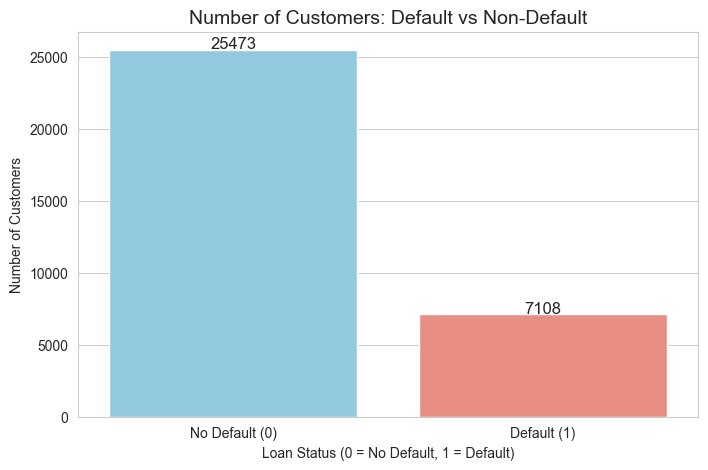

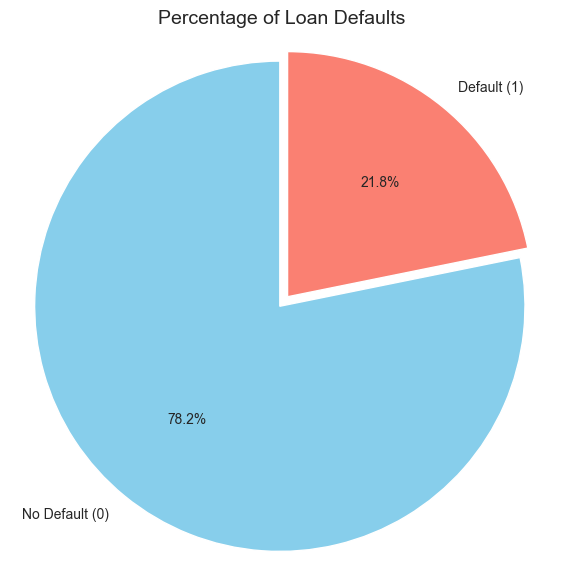

✅ Plots saved successfully!
Total customers: 32581
No Default (0): 25473 (78.2%)
Default (1): 7108 (21.8%)


In [7]:
# Step 6: Visualizing the Target Variable (loan_status) - FIXED with folder creation

import os

# Create the outputs/plots folder if it doesn't exist
os.makedirs('../outputs/plots', exist_ok=True)
os.makedirs('../outputs/results', exist_ok=True)

print("✅ Output folders created/checked successfully!")

# Count the number of defaults and non-defaults
target_counts = df['loan_status'].value_counts()

# 1. Bar Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=target_counts.index, y=target_counts.values, 
            hue=target_counts.index, 
            palette=['skyblue', 'salmon'], 
            legend=False)
plt.title('Number of Customers: Default vs Non-Default', fontsize=14)
plt.xlabel('Loan Status (0 = No Default, 1 = Default)')
plt.ylabel('Number of Customers')
plt.xticks([0, 1], ['No Default (0)', 'Default (1)'])

# Add value labels on top of bars
for i, count in enumerate(target_counts.values):
    plt.text(i, count + 100, str(count), ha='center', fontsize=12)

# Save plot - correct path from notebooks/
plt.savefig('../outputs/plots/member1_target_distribution_bar.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Pie Chart
plt.figure(figsize=(7, 7))
plt.pie(target_counts.values, 
        labels=['No Default (0)', 'Default (1)'],
        autopct='%1.1f%%',
        colors=['skyblue', 'salmon'],
        startangle=90,
        explode=(0, 0.05))
plt.title('Percentage of Loan Defaults', fontsize=14)
plt.axis('equal')

plt.savefig('../outputs/plots/member1_target_distribution_pie.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Plots saved successfully!")
print(f"Total customers: {len(df)}")
print(f"No Default (0): {target_counts.get(0, 0)} ({target_counts.get(0, 0)/len(df)*100:.1f}%)")
print(f"Default (1): {target_counts.get(1, 0)} ({target_counts.get(1, 0)/len(df)*100:.1f}%)")

=== Visualizing Numerical Features ===


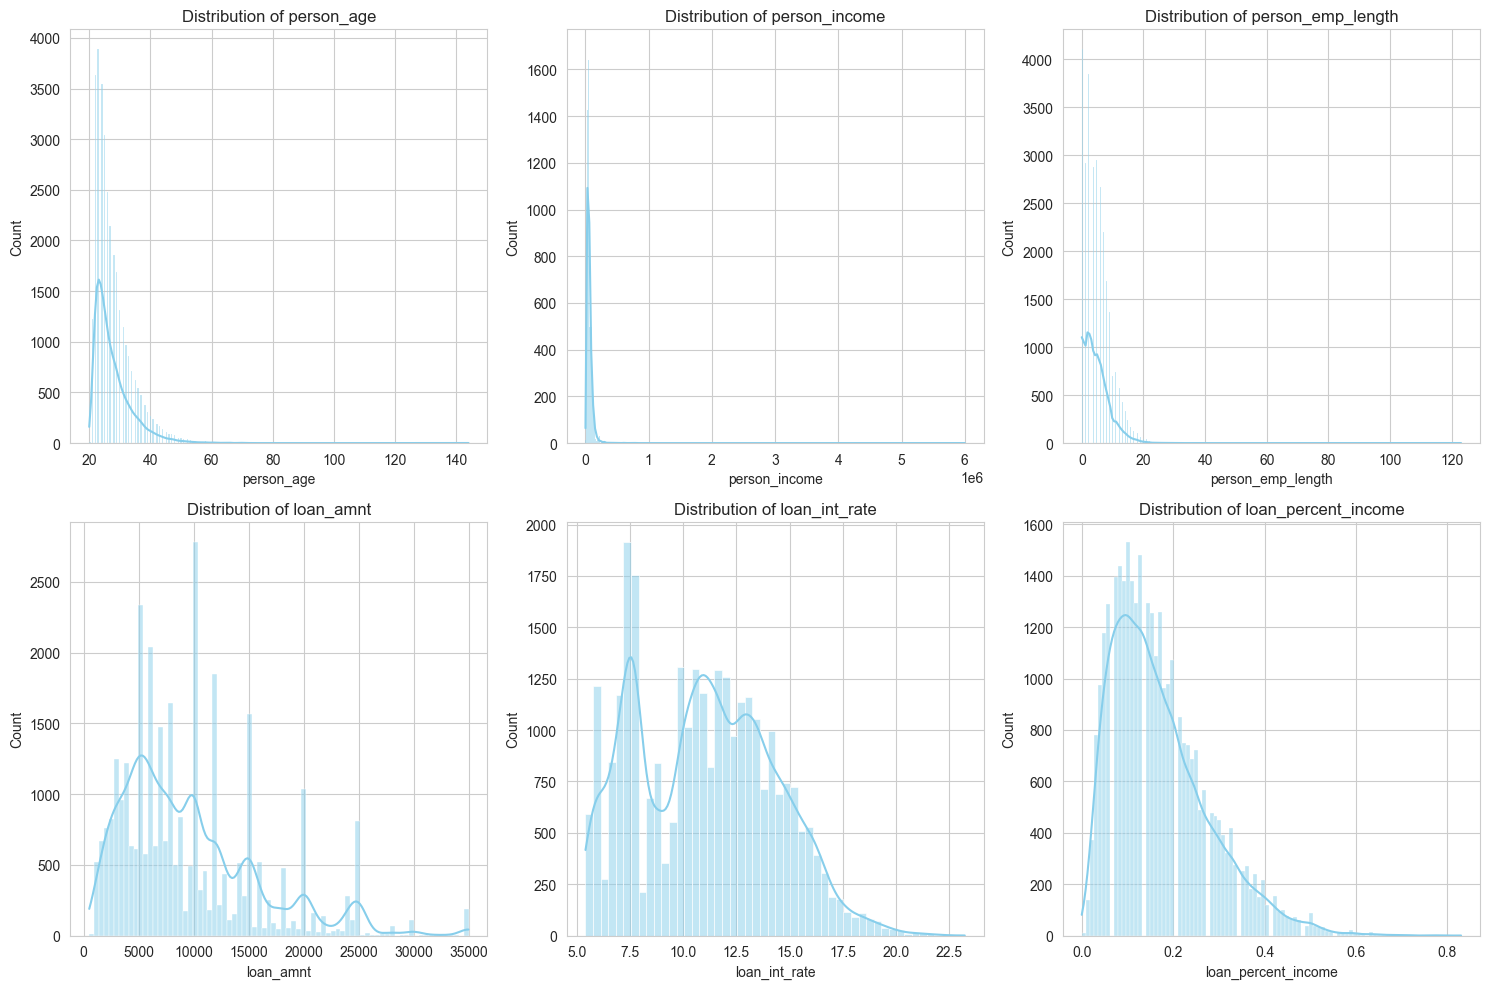

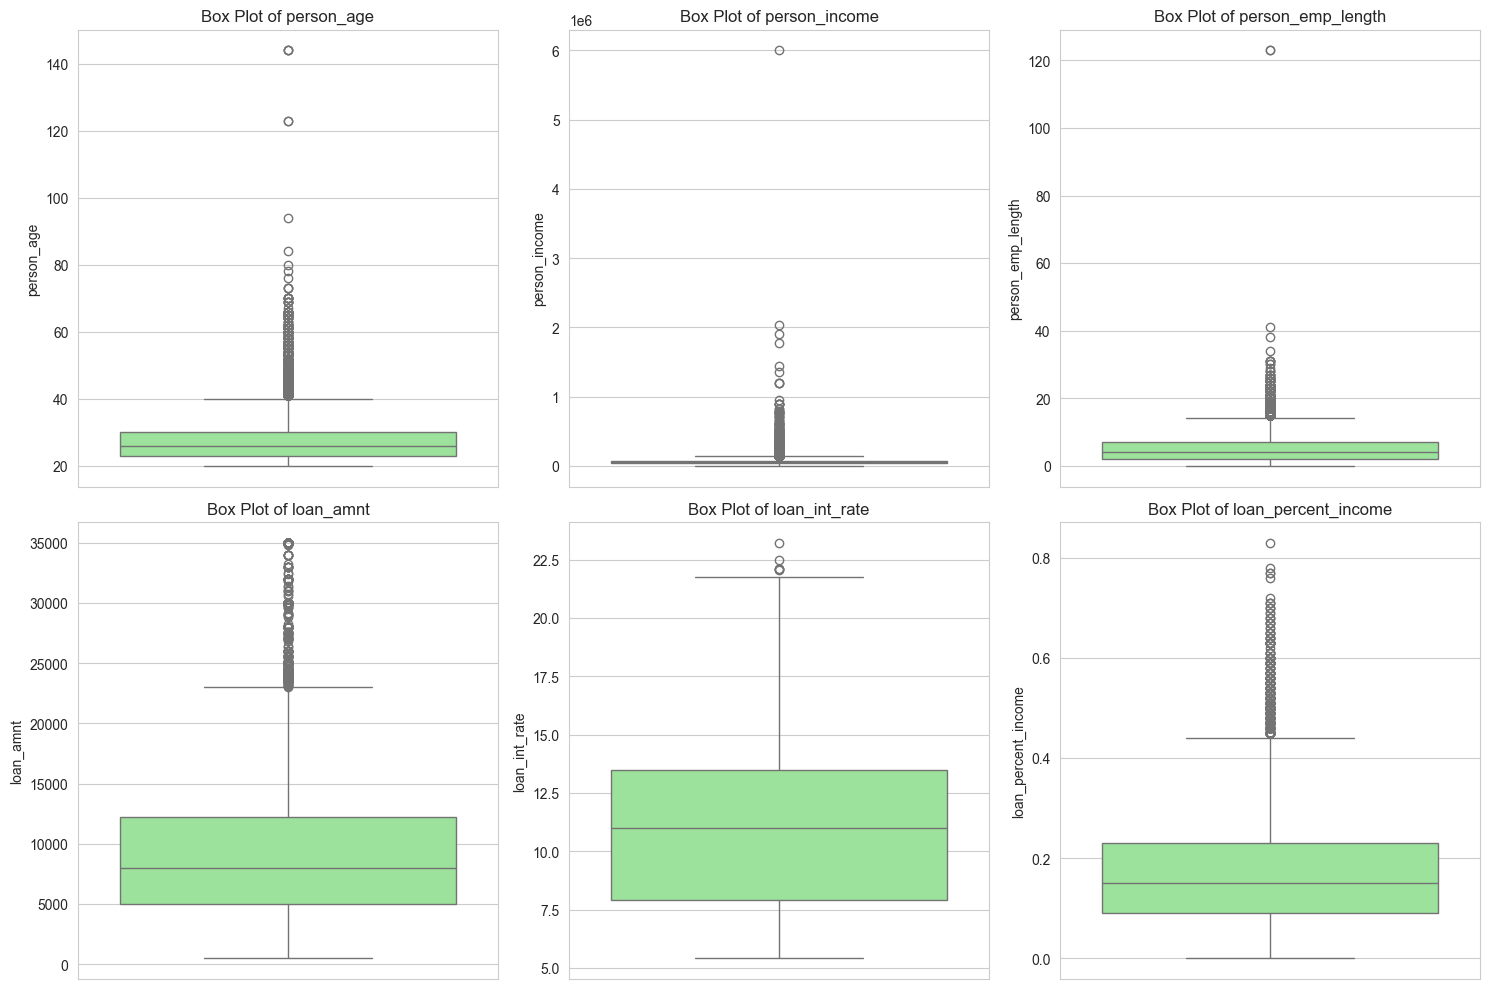

✅ Numerical feature plots saved in outputs/plots/


In [8]:
# Step 7: Visualizing Numerical Features - Histograms and Box Plots

# First, make sure output folder exists
import os
os.makedirs('../outputs/plots', exist_ok=True)

numerical_cols = ['person_age', 'person_income', 'person_emp_length', 
                  'loan_amnt', 'loan_int_rate', 'loan_percent_income']

print("=== Visualizing Numerical Features ===")

# Histograms (distribution)
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.savefig('../outputs/plots/member1_numerical_histograms.png', dpi=300, bbox_inches='tight')
plt.show()

# Box plots (to see outliers and spread)
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Box Plot of {col}')

plt.tight_layout()
plt.savefig('../outputs/plots/member1_numerical_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Numerical feature plots saved in outputs/plots/")

=== Visualizing Categorical Features ===


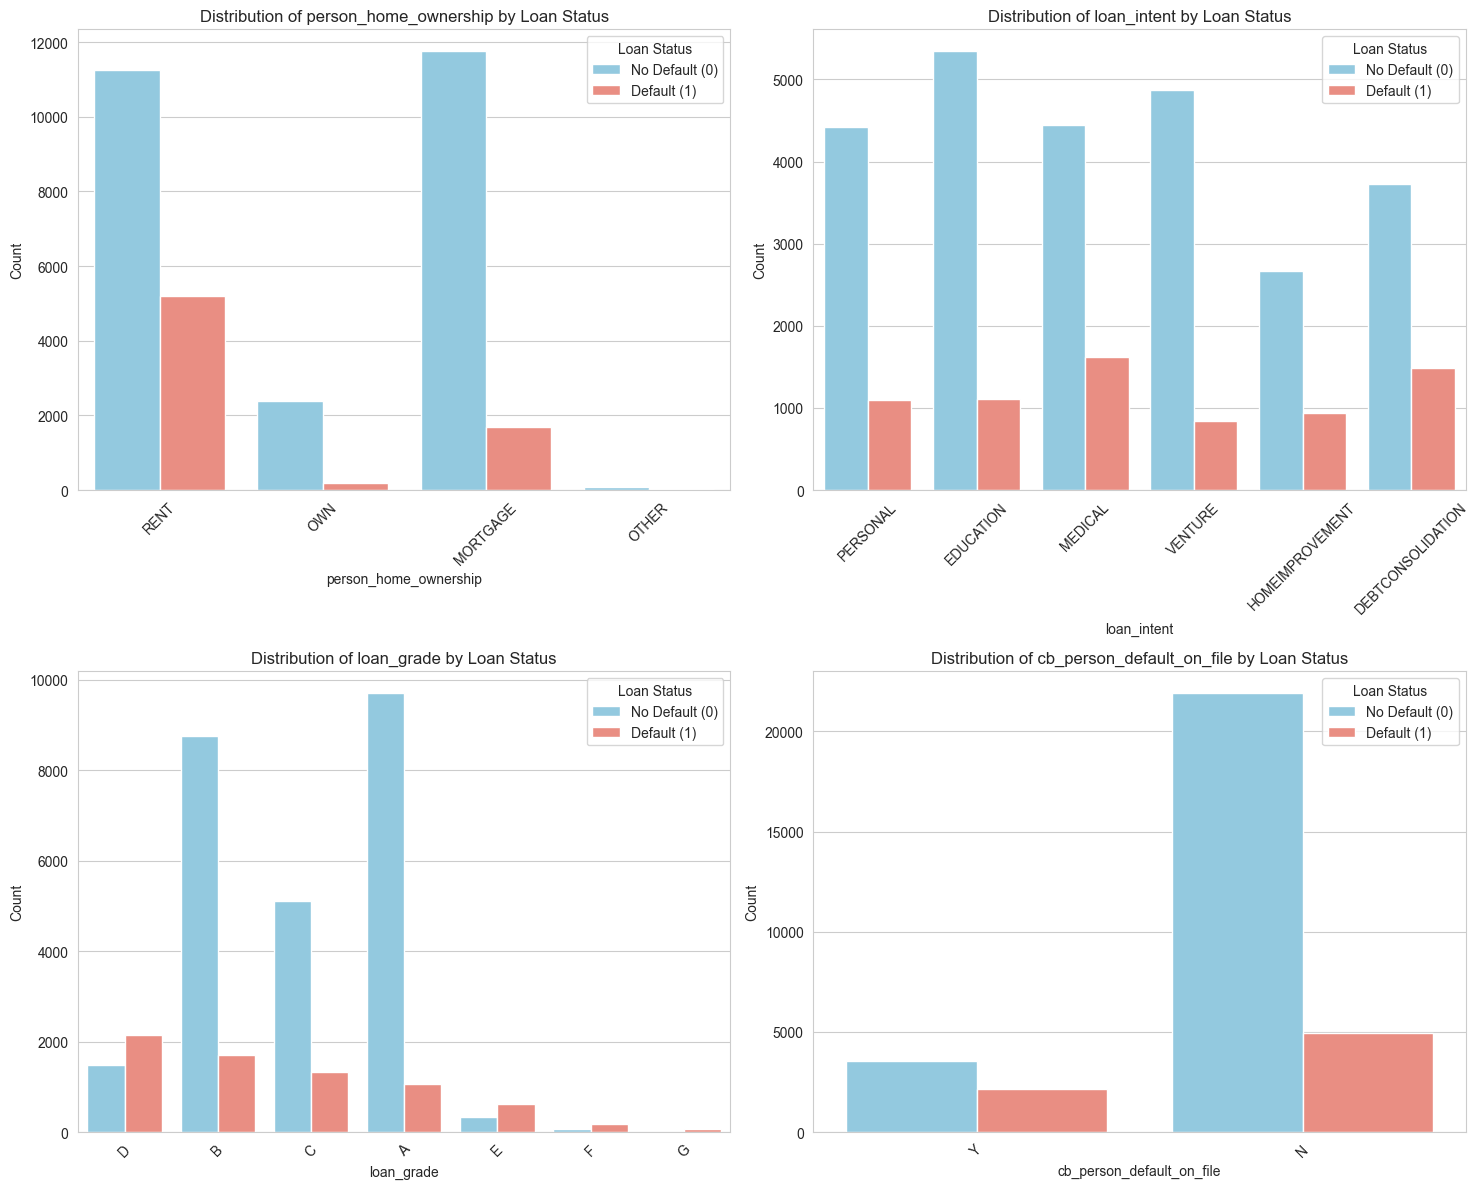

✅ Categorical feature plots saved in outputs/plots/

=== Value counts for person_home_ownership ===
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

By loan_status:
loan_status               0     1
person_home_ownership            
MORTGAGE               87.4  12.6
OTHER                  69.2  30.8
OWN                    92.5   7.5
RENT                   68.4  31.6

=== Value counts for loan_intent ===
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

By loan_status:
loan_status           0     1
loan_intent                  
DEBTCONSOLIDATION  71.4  28.6
EDUCATION          82.8  17.2
HOMEIMPROVEMENT    73.9  26.1
MEDICAL            73.3  26.7
PERSONAL           80.1  19.9
VENTURE            85.2  14.8

=== Value counts for loan_grade ===
loan_grade
A    10777
B    10451


In [9]:
# Step 8: Visualizing Categorical Features

import os
os.makedirs('../outputs/plots', exist_ok=True)

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

print("=== Visualizing Categorical Features ===")

# Create count plots for each categorical column
plt.figure(figsize=(15, 12))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=df, x=col, hue='loan_status', palette=['skyblue', 'salmon'])
    plt.title(f'Distribution of {col} by Loan Status')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(title='Loan Status', labels=['No Default (0)', 'Default (1)'])

plt.tight_layout()
plt.savefig('../outputs/plots/member1_categorical_countplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Categorical feature plots saved in outputs/plots/")

# Also print value counts for each categorical column
for col in categorical_cols:
    print(f"\n=== Value counts for {col} ===")
    print(df[col].value_counts())
    print("\nBy loan_status:")
    print(pd.crosstab(df[col], df['loan_status'], normalize='index').round(3) * 100)

=== Correlation Analysis ===


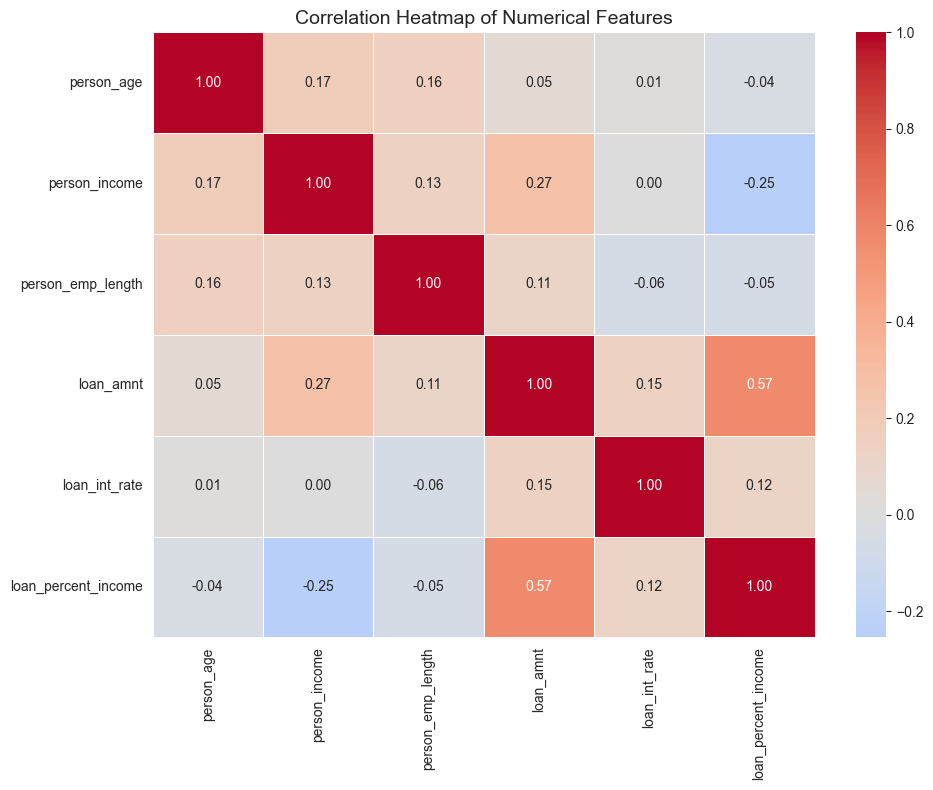

✅ Correlation heatmap saved in outputs/plots/

=== Average Values by Loan Status (0 = No Default, 1 = Default) ===


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income
loan_status,,,,,,
0,27.81,70804.36,4.97,9237.46,10.44,0.15
1,27.47,49125.65,4.14,10850.50,13.06,0.25



✅ Table saved as CSV in outputs/results/


In [10]:
# Step 9: Correlation Heatmap and Relationship with Target

import os
os.makedirs('../outputs/plots', exist_ok=True)

print("=== Correlation Analysis ===")

# Select only numerical columns for correlation
numerical_cols = ['person_age', 'person_income', 'person_emp_length', 
                  'loan_amnt', 'loan_int_rate', 'loan_percent_income']

# Create correlation matrix
corr_matrix = df[numerical_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/plots/member1_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Correlation heatmap saved in outputs/plots/")

# Relationship of numerical features with target (mean values)
print("\n=== Average Values by Loan Status (0 = No Default, 1 = Default) ===")
mean_by_status = df.groupby('loan_status')[numerical_cols].mean().round(2)
display(mean_by_status)

# Save this table as image for report (optional but good for marks)
mean_by_status.to_csv('../outputs/results/member1_mean_by_loan_status.csv')

print("\n✅ Table saved as CSV in outputs/results/")